In [19]:
import pandas as pd
import numpy as np

In [20]:
df=pd.read_csv('adult_with_headers.csv')

In [21]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [23]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [24]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [25]:
df.replace(' ?', np.nan, inplace=True)

In [26]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,1843
relationship,0
race,0
sex,0


In [27]:
df.dropna(inplace=True)

In [28]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [29]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [30]:
scaler = StandardScaler()
df_standard = df.copy()
df_standard[num_cols] = scaler.fit_transform(df[num_cols])

In [31]:
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = minmax.fit_transform(df[num_cols])

In [32]:
cat_cols = df.select_dtypes(include=['object']).columns

In [33]:
from sklearn.preprocessing import OneHotEncoder

# Re-calculate cat_cols to ensure it reflects the most current state of df's columns
# This addresses potential discrepancies if df was modified after cat_cols was last defined.
cat_cols = df.select_dtypes(include=['object']).columns

small_cat = [col for col in cat_cols if df[col].nunique() < 5]

df = pd.get_dummies(df, columns=small_cat)

In [34]:
from sklearn.preprocessing import LabelEncoder

# Re-calculate cat_cols to ensure it reflects the most current state of df's columns
# after one-hot encoding of small_cat columns.
cat_cols = df.select_dtypes(include=['object']).columns

large_cat = [col for col in cat_cols if df[col].nunique() >= 5]

le = LabelEncoder()
for col in large_cat:
    df[col] = le.fit_transform(df[col])

In [35]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,45,65,100], labels=[0,1,2,3])

In [36]:
df['hours_category'] = pd.cut(df['hours_per_week'], bins=[0,25,40,60,100], labels=[0,1,2,3])

In [37]:
import matplotlib.pyplot as plt

<Axes: >

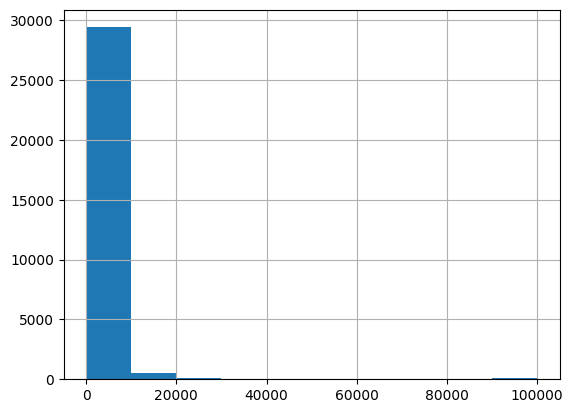

In [38]:
df['capital_gain'].hist()

In [39]:
df['capital_gain_log'] = np.log1p(df['capital_gain'])

In [40]:
from sklearn.ensemble import IsolationForest

In [41]:
iso = IsolationForest(contamination=0.05)

In [42]:
outliers = iso.fit_predict(df[num_cols])

In [43]:
df = df[outliers == 1]

In [44]:
!pip install ppscore
import ppscore as pps

  Preparing metadata (setup.py) ... done
  Created wheel for ppscore: filename=ppscore-1.3.1-py2.py3-none-any.whl size=13180 sha256=b33f6048629906985ad8052836de7da88b1ae60df156687cc9b0b419d0538ad5
  Stored in directory: /root/.cache/pip/wheels/84/0d/d6/ec295c574356939e9877f87c4eb195ba97440b0cd97cadf32a
Successfully built ppscore


In [45]:
pps_matrix = pps.matrix(df)

In [46]:
pps_matrix.head()

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.0000,1.000000,None
1,age,workclass,0.0,regression,True,mean absolute error,0.4426,0.567296,DecisionTreeRegressor()
2,age,fnlwgt,0.0,regression,True,mean absolute error,73549.4768,74228.556791,DecisionTreeRegressor()
3,age,education,0.0,regression,True,mean absolute error,2.6166,2.699055,DecisionTreeRegressor()
4,age,education_num,0.0,regression,True,mean absolute error,1.7948,1.838687,DecisionTreeRegressor()


In [47]:
import seaborn as sns

In [48]:
corr = df.corr()

<Axes: >

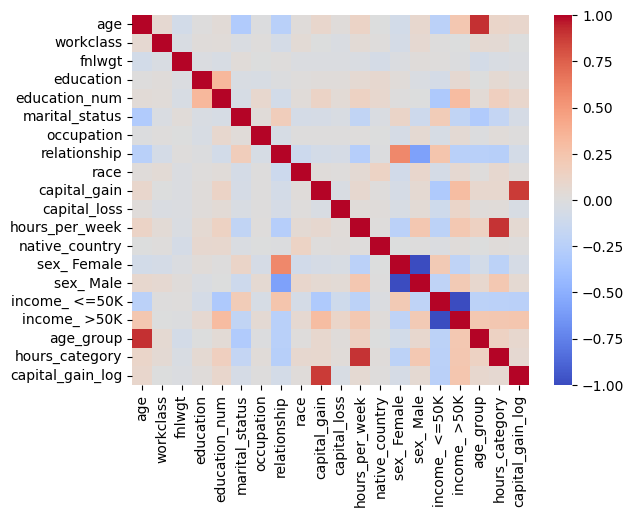

In [49]:
sns.heatmap(corr, annot=False, cmap='coolwarm')